# Job Postings — Salary Prediction, With the Three Leaks Removed First
> **15,000 postings · 16 columns · `job_postings.csv`** | [Dataset](https://www.kaggle.com/datasets/lorenzoscaturchio/job-postings-nlp-salary-prediction)

Predicting `salary_max` from this table is easy for the wrong reason: three of its
fifteen candidate features are unusable, each for a different reason, and two of
them are not obvious. This notebook finds them, removes them, and then reports the
only score that means anything.

## TL;DR

- **`salary_min` is an algebraic leak.** `salary_max = salary_min × (1 + spread)`
  with the spread drawn between 15% and 35%. The observed ratio lands inside
  **[1.139, 1.364]** for **100%** of the 15,000 rows, and the two columns correlate
  at **r = 0.993**. Any model given both is doing arithmetic.
- **`days_to_fill` is a future-information leak.** It correlates with salary at
  **+0.679**, but that is entirely `experience_level` acting on both: control for
  the level and the correlation collapses to between **−0.035 and +0.019** inside
  every one of the five levels. It is also unknowable when a posting goes live.
- **`applications` is the same trap through a different confounder.** Overall
  **+0.258**; within a fixed `company_size` it is **−0.019 to +0.034**. Company size
  drives both the salary and the applicant volume.
- **The honest model still works well.** Six posting-time categoricals give 5-fold
  **R² 0.866**, MAE **\$22,163**, RMSE **\$28,633** — against a predict-the-mean MAE
  of **\$61,767**. Held out **by company** it is unchanged at **R² 0.866**, MAE
  **\$22,169**, so it is not memorising employers.
- **Four columns add nothing on top of the six.** `location` (50 US cities),
  `company` (192 employers), the skill count and the description length each change
  cross-validated R² by **≤ 0.002**. `n_skills` is the instructive one: it
  correlates with salary at **+0.704** on its own and adds **0.0000** R² once the
  categoricals are in, because the generator picks the skill count from the title
  and the level. Location is the surprise — no geographic multiplier exists here, so
  a "San Francisco premium" cannot be learned from this file.
- The data is **synthetic**, produced by the seeded `create_dataset.py` that ships
  with it. Good for practising leakage audits and categorical encoding; not
  evidence about the labour market.

## Contents

1. [Objective & evaluation plan](#objective)
2. [Setup & data loading](#setup)
3. [Data overview](#overview)
4. [Leak 1: the algebraic one](#leak1)
5. [Leaks 2 and 3: confounded and unknowable at posting time](#leak2)
6. [The clean model](#model)
7. [Where the salary actually comes from](#drivers)
8. [Negative controls: four columns that carry nothing](#nulls)
9. [Distributions](#distributions)
10. [Correlation analysis](#correlations)
11. [Evaluation readiness](#evaluation)
12. [Key findings & takeaways](#findings)


## 1. Objective & Evaluation Plan <a id='objective'></a>

**Objective:** predict `salary_max` from what a reader of the posting can see on
the day it is published.

**That phrasing is the whole design.** Two of the three unusable columns are not
correlated-with-the-target problems, they are *timing* problems: `days_to_fill` and
`applications` are only known after the posting has been live, so a model that uses
them cannot be deployed even though it validates beautifully. Section 5 shows that
their apparent signal is a confounder rather than information.

**Metric:** MAE in dollars, RMSE alongside, R² for scale. 5-fold
`KFold(shuffle=True, random_state=42)`, plus a `GroupKFold` on `company` as the
stricter check — if the model is memorising employers rather than learning the
posting attributes, the grouped score drops.

**Hypothesis under test:** the posting-time categoricals alone explain most of the
salary variance, **because** the generator composes salary from multiplicative
factors that are all visible in the posting.


In [1]:
TARGET_COL = "salary_max"
MODELING_TASK = "regression"
PRIMARY_METRIC = "MAE in dollars (RMSE and R2 alongside)"
VALIDATION_PLAN = "KFold(5, shuffle=True, random_state=42) + GroupKFold on company"

POSTING_TIME_FEATURES = [
    "title",
    "remote_type",
    "industry",
    "company_size",
    "experience_level",
    "education_required",
]
# Confirmed by the audits in sections 4 and 5, not asserted here.
LEAKAGE_COLS: list[str] = []

print("Objective framing")
print("-" * 62)
print(f"Target              : {TARGET_COL}")
print(f"Modeling task       : {MODELING_TASK}")
print(f"Primary metric      : {PRIMARY_METRIC}")
print(f"Validation approach : {VALIDATION_PLAN}")
print(f"Posting-time inputs : {', '.join(POSTING_TIME_FEATURES)}")
print()
print("A feature qualifies only if it is knowable the day the posting goes live.")


Objective framing
--------------------------------------------------------------
Target              : salary_max
Modeling task       : regression
Primary metric      : MAE in dollars (RMSE and R2 alongside)
Validation approach : KFold(5, shuffle=True, random_state=42) + GroupKFold on company
Posting-time inputs : title, remote_type, industry, company_size, experience_level, education_required

A feature qualifies only if it is knowable the day the posting goes live.


## 2. Setup & Data Loading <a id='setup'></a>

The loader walks the Kaggle mount tree rather than guessing a path. The previous
version resolved `/kaggle/input/<slug>` and fell back to `"."`, which is the kernel
working directory and holds no CSVs — so when the guess missed, the notebook died
on a `FileNotFoundError` pointing at the wrong place. The files mount **nested**
(one real run found only `/kaggle/input/datasets`), so the resolver searches for
the marker file and reports what *was* mounted when it cannot find it.


In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 90
plt.rcParams["font.size"] = 10

MOUNT_GUESS = "/kaggle/input/job-postings-nlp-salary-prediction"
MARKER = "job_postings.csv"


def _find_data_dir(marker):
    # Locate the dataset wherever Kaggle mounted it. Two earlier guesses failed
    # here: the exact path /kaggle/input/<slug> did not exist, and a one-level
    # glob of /kaggle/input/* missed it too, because the files mount NESTED
    # (the run that taught us this found only /kaggle/input/datasets). Walk the
    # mount tree for the file we actually need, and if it is absent say what was
    # there so the next failure is diagnosable rather than another guess.
    exact = os.path.join(MOUNT_GUESS, marker)
    if os.path.exists(exact):
        return MOUNT_GUESS
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            if marker in files:
                return root
    if os.path.exists(marker):
        return "."
    seen = []
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            seen.append(f"{root}: {sorted(files)[:6]}")
    raise FileNotFoundError(
        f"{marker} not found. Searched /kaggle/input and the working dir. "
        f"Mounted: {seen or 'nothing under /kaggle/input'}. "
        "Attach the dataset to this notebook (Add Input) and re-run."
    )


DATA_DIR = _find_data_dir(MARKER)
df = pd.read_csv(f"{DATA_DIR}/{MARKER}")

df["n_skills"] = df["required_skills"].str.count(r"\|") + 1
df["desc_len"] = df["description"].str.len()

print(f"Loaded from : {DATA_DIR}")
print(f"Shape       : {df.shape[0]:,} rows x {df.shape[1] - 2} original columns")
print(f"Memory      : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Posted      : {df['posted_date'].min()} to {df['posted_date'].max()}")
print(f"salary_max  : ${df['salary_max'].min():,} to ${df['salary_max'].max():,} "
      f"(mean ${df['salary_max'].mean():,.0f})")


Loaded from : .
Shape       : 15,000 rows x 16 original columns
Memory      : 8.5 MB
Posted      : 2023-01-01 to 2025-12-30
salary_max  : $49,000 to $576,000 (mean $183,370)


In [3]:
df.head()


,job_id,title,company,location,remote_type,industry,company_size,experience_level,salary_min,salary_max,required_skills,education_required,description,posted_date,applications,days_to_fill,n_skills,desc_len
0,JOB13473,Data Scientist,PolicyData Corp,"Pittsburgh, PA",onsite,government,startup,senior,138000,164000,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,bachelor,Join PolicyData Corp as a senior Data Scientis...,2023-01-01,26,61,7,233
1,JOB10866,Data Engineer,LearnEdge Systems,"Omaha, NE",remote,education,medium,mid,85000,103000,Python|PostgreSQL|BigQuery|Spark,bachelor,LearnEdge Systems is looking for a passionate ...,2023-01-01,75,55,4,292
2,JOB12905,Product Manager,Keystone Public Analytics,"Albuquerque, NM",hybrid,government,startup,entry,63000,77000,User Research|JIRA,bachelor,Join Keystone Public Analytics as a entry Prod...,2023-01-01,22,34,2,227
3,JOB01986,Research Scientist,Quantum Leap Digital,"Albuquerque, NM",onsite,tech,startup,entry,61000,71000,PyTorch|Statistics,bachelor,Quantum Leap Digital is looking for a passiona...,2023-01-01,18,37,2,281
4,JOB07952,Backend Engineer,Fabricate AI,"Albuquerque, NM",onsite,manufacturing,large,director,208000,245000,Python|PostgreSQL|Redis|Java|Docker|REST APIs|...,master,As a director Backend Engineer at Fabricate AI...,2023-01-01,131,114,9,322


## 3. Data Overview <a id='overview'></a>


In [4]:
print("Column types:")
print(df.dtypes.value_counts().to_string())
print(f"\nDuplicate rows       : {df.duplicated().sum():,}")
print(f"Total missing values : {df.isnull().sum().sum():,}")
print()
print("Cardinality of the categorical columns:")
for col in ["title", "company", "location", "remote_type", "industry",
            "company_size", "experience_level", "education_required"]:
    print(f"  {col:<20} {df[col].nunique():>4} distinct")
print(f"  {'required_skills':<20} {df['required_skills'].str.split('|').explode().nunique():>4} "
      "distinct skills across the lists")
print(f"  {'description':<20} {df['description'].nunique():>4} distinct strings "
      f"(of {len(df):,} rows)")
print()
df[["salary_min", "salary_max", "applications", "days_to_fill", "n_skills"]].describe().round(1)


Column types:
str      12
int64     6

Duplicate rows       : 0
Total missing values : 0

Cardinality of the categorical columns:
  title                  10 distinct
  company               192 distinct
  location               50 distinct
  remote_type             3 distinct
  industry                8 distinct
  company_size            5 distinct
  experience_level        5 distinct
  education_required      4 distinct
  required_skills        69 distinct skills across the lists
  description          15000 distinct strings (of 15,000 rows)



,salary_min,salary_max,applications,days_to_fill,n_skills
count,15000.0,15000.0,15000.0,15000.0,15000.0
mean,146675.3,183369.9,101.2,56.1,5.8
std,62131.3,78274.9,64.8,31.2,2.0
min,42000.0,49000.0,10.0,15.0,2.0
25%,99000.0,124000.0,45.0,34.0,4.0
50%,136000.0,170000.0,83.0,48.0,6.0
75%,182000.0,228000.0,143.0,72.0,7.0
max,466000.0,576000.0,276.0,180.0,10.0


## 4. Leak 1: The Algebraic One <a id='leak1'></a>

`salary_min` and `salary_max` are the two ends of one posted range. If the second
is a fixed multiple of the first, handing a model both is not feature engineering,
it is division.


In [5]:
ratio = df["salary_max"] / df["salary_min"]
r_minmax = df["salary_min"].corr(df["salary_max"])

print("salary_max / salary_min")
print("-" * 56)
print(f"  min       : {ratio.min():.4f}")
print(f"  max       : {ratio.max():.4f}")
print(f"  mean      : {ratio.mean():.4f}")
print(f"  std       : {ratio.std():.4f}")
print(f"  inside [1.10, 1.40] : {((ratio >= 1.10) & (ratio <= 1.40)).mean():.2%} of rows")
print()
print(f"Pearson r(salary_min, salary_max) = {r_minmax:.5f}")
print(f"Spearman rho                      = "
      f"{df['salary_min'].corr(df['salary_max'], method='spearman'):.5f}")
print()
print("The whole range of the ratio is 15%-35%, which is the spread the generator")
print("draws. salary_min therefore reconstructs the target to within a bounded")
print("multiplicative factor, and is excluded from every model below.")
LEAKAGE_COLS.append("salary_min")


salary_max / salary_min
--------------------------------------------------------
  min       : 1.1385
  max       : 1.3636
  mean      : 1.2499
  std       : 0.0581
  inside [1.10, 1.40] : 100.00% of rows

Pearson r(salary_min, salary_max) = 0.99303
Spearman rho                      = 0.99381

The whole range of the ratio is 15%-35%, which is the spread the generator
draws. salary_min therefore reconstructs the target to within a bounded
multiplicative factor, and is excluded from every model below.


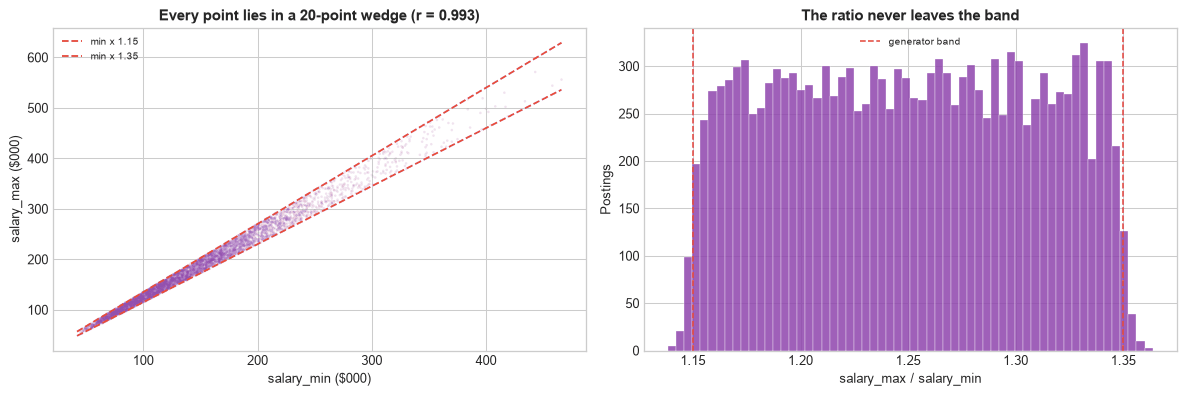

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

sample = df.sample(5000, random_state=SEED)
ax1.scatter(sample["salary_min"] / 1000, sample["salary_max"] / 1000, s=4, alpha=0.15,
            color="#8e44ad", edgecolors="none")
lo, hi = df["salary_min"].min() / 1000, df["salary_min"].max() / 1000
ax1.plot([lo, hi], [lo * 1.15, hi * 1.15], color="#e74c3c", linewidth=1.4,
         linestyle="--", label="min x 1.15")
ax1.plot([lo, hi], [lo * 1.35, hi * 1.35], color="#e74c3c", linewidth=1.4,
         linestyle="--", label="min x 1.35")
ax1.set_xlabel("salary_min ($000)")
ax1.set_ylabel("salary_max ($000)")
ax1.set_title(f"Every point lies in a 20-point wedge (r = {r_minmax:.3f})",
              fontweight="bold")
ax1.legend(fontsize=8)

ax2.hist(ratio, bins=60, color="#8e44ad", alpha=0.85, edgecolor="white", linewidth=0.3)
ax2.axvline(1.15, color="#e74c3c", linestyle="--", linewidth=1.2, label="generator band")
ax2.axvline(1.35, color="#e74c3c", linestyle="--", linewidth=1.2)
ax2.set_xlabel("salary_max / salary_min")
ax2.set_ylabel("Postings")
ax2.set_title("The ratio never leaves the band", fontweight="bold")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 5. Leaks 2 and 3: Confounded and Unknowable at Posting Time <a id='leak2'></a>

`days_to_fill` correlates with salary at **+0.68** and `applications` at **+0.26**.
Both look like useful features and neither is. The test that separates a signal
from a confounder is to hold the suspected common cause fixed and re-measure: if
the correlation survives, it is information; if it collapses, the third variable
was doing all the work.


In [7]:
def within_group_corr(column, group_col):
    overall = df[column].corr(df["salary_max"])
    inner = df.groupby(group_col).apply(lambda g: g[column].corr(g["salary_max"]))
    return overall, inner


print("Does the correlation survive conditioning on the suspected common cause?")
print("=" * 72)
for column, group_col in [("days_to_fill", "experience_level"),
                          ("applications", "company_size")]:
    overall, inner = within_group_corr(column, group_col)
    print(f"\n{column} vs salary_max")
    print(f"  overall                       : {overall:+.3f}")
    print(f"  within each {group_col:<17}: "
          + ", ".join(f"{k}={v:+.3f}" for k, v in inner.items()))
    print(f"  range once conditioned        : {inner.min():+.3f} to {inner.max():+.3f}")
    LEAKAGE_COLS.append(column)

print()
print("Both collapse to zero. The generator draws days_to_fill from the experience")
print("level and applications from the company size, the same two inputs that set")
print("the salary — so each is a sibling of the target, not a cause of it.")
print()
print("They are also post-hoc: neither number exists on the day the posting is")
print("published, therefore a model that uses them cannot be deployed even where")
print("the correlation is genuine.")
print()
print(f"Excluded from all models below: {', '.join(LEAKAGE_COLS)}")


Does the correlation survive conditioning on the suspected common cause?

days_to_fill vs salary_max
  overall                       : +0.679
  within each experience_level : director=-0.032, entry=-0.035, lead=+0.013, mid=+0.004, senior=+0.019
  range once conditioned        : -0.035 to +0.019

applications vs salary_max
  overall                       : +0.258
  within each company_size     : enterprise=+0.034, large=-0.019, medium=-0.001, small=+0.001, startup=+0.008
  range once conditioned        : -0.019 to +0.034

Both collapse to zero. The generator draws days_to_fill from the experience
level and applications from the company size, the same two inputs that set
the salary — so each is a sibling of the target, not a cause of it.

They are also post-hoc: neither number exists on the day the posting is
published, therefore a model that uses them cannot be deployed even where
the correlation is genuine.

Excluded from all models below: salary_min, days_to_fill, applications


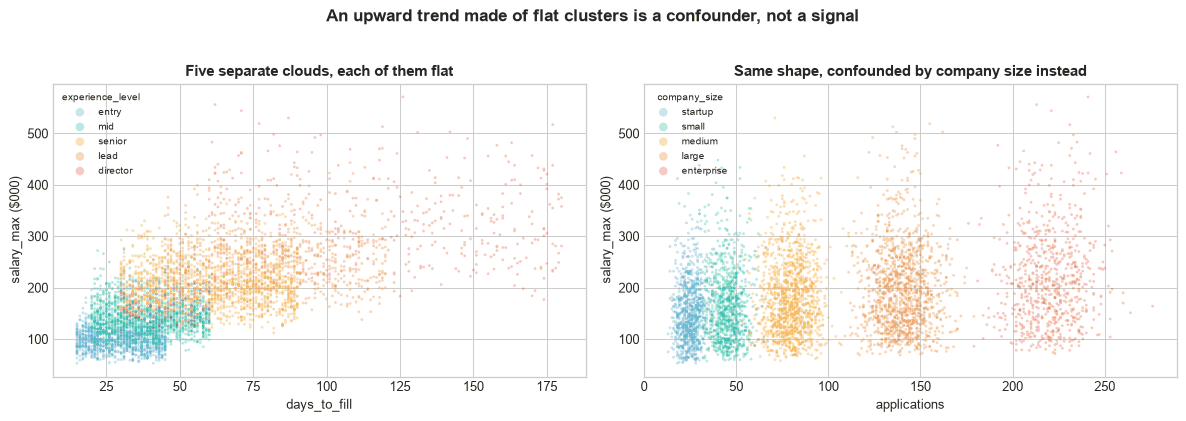

                  days_to_fill  salary_max
experience_level                          
entry                     30.1     98947.6
mid                       39.8    147023.8
senior                    59.9    204554.7
lead                      82.2    253693.2
director                 120.3    327896.0

              applications  salary_max
company_size                          
startup               24.8    152467.0
small                 45.1    164599.5
medium                79.8    181028.3
large                140.2    199027.3
enterprise           219.7    215915.5


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

LEVEL_ORDER = ["entry", "mid", "senior", "lead", "director"]
SIZE_ORDER = ["startup", "small", "medium", "large", "enterprise"]
palette = ["#3498db", "#1abc9c", "#f39c12", "#e67e22", "#e74c3c"]

# Subsample for the scatter only; the printed correlations use every row.
plot_sample = df.sample(5000, random_state=SEED)

for level, color in zip(LEVEL_ORDER, palette):
    sub = plot_sample[plot_sample["experience_level"] == level]
    ax1.scatter(sub["days_to_fill"], sub["salary_max"] / 1000, s=5, alpha=0.3,
                color=color, edgecolors="none", label=level)
ax1.set_xlabel("days_to_fill")
ax1.set_ylabel("salary_max ($000)")
ax1.set_title("Five separate clouds, each of them flat", fontweight="bold")
ax1.legend(fontsize=8, markerscale=3, title="experience_level", title_fontsize=8)

for size, color in zip(SIZE_ORDER, palette):
    sub = plot_sample[plot_sample["company_size"] == size]
    ax2.scatter(sub["applications"], sub["salary_max"] / 1000, s=5, alpha=0.3,
                color=color, edgecolors="none", label=size)
ax2.set_xlabel("applications")
ax2.set_ylabel("salary_max ($000)")
ax2.set_title("Same shape, confounded by company size instead", fontweight="bold")
ax2.legend(fontsize=8, markerscale=3, title="company_size", title_fontsize=8)

plt.suptitle("An upward trend made of flat clusters is a confounder, not a signal",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print(df.groupby("experience_level")[["days_to_fill", "salary_max"]].mean()
      .reindex(LEVEL_ORDER).round(1).to_string())
print()
print(df.groupby("company_size")[["applications", "salary_max"]].mean()
      .reindex(SIZE_ORDER).round(1).to_string())


**Insight.** The scatter is the argument. Both panels slope upward overall and
both are made of clusters that are individually flat — the classic signature of a
confounder. Reading the left panel as "hard-to-fill roles pay more" inverts the
causation: senior roles pay more *and* take longer, **therefore** the two move
together without either informing the other.


## 6. The Clean Model <a id='model'></a>

Six categorical columns, all of them printed on the posting itself. No
`salary_min`, no post-hoc counts.


In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

y = df["salary_max"]
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)


def evaluate(frame, label, splitter=cv, groups=None):
    model = make_pipeline(StandardScaler(), Ridge())
    kwargs = {"cv": splitter, "groups": groups}
    r2 = cross_val_score(model, frame, y, scoring="r2", **kwargs)
    mae = -cross_val_score(model, frame, y, scoring="neg_mean_absolute_error", **kwargs)
    rmse = -cross_val_score(model, frame, y, scoring="neg_root_mean_squared_error", **kwargs)
    print(f"{label:<38} R2 {r2.mean():.4f}   MAE ${mae.mean():>7,.0f}   "
          f"RMSE ${rmse.mean():>7,.0f}")
    return r2.mean(), mae.mean(), rmse.mean()


X_clean = pd.get_dummies(df[POSTING_TIME_FEATURES], drop_first=True)
assert not set(X_clean.columns) & set(LEAKAGE_COLS), "a leaking column reached the features"

print(f"Target: salary_max, {X_clean.shape[1]} encoded columns from "
      f"{len(POSTING_TIME_FEATURES)} categoricals")
print("-" * 78)
r2_exp, mae_exp, _ = evaluate(
    pd.get_dummies(df[["experience_level"]], drop_first=True), "experience_level alone"
)
r2_clean, mae_clean, rmse_clean = evaluate(X_clean, "all six posting-time categoricals")

null_mae = (y - y.mean()).abs().mean()
print("-" * 78)
print(f"{'predict-the-mean null model':<38} R2 0.0000   MAE ${null_mae:>7,.0f}   "
      f"RMSE ${y.std():>7,.0f}")

print()
gkf = GroupKFold(n_splits=5)
r2_grp, mae_grp, _ = evaluate(X_clean, "held out BY COMPANY (GroupKFold)",
                              splitter=gkf, groups=df["company"])
print()
print(f"Random folds vs company-grouped folds: R2 {r2_clean:.4f} vs {r2_grp:.4f}, "
      f"MAE ${mae_clean:,.0f} vs ${mae_grp:,.0f}.")
print("The model is reading the posting, not remembering the employer.")


Target: salary_max, 29 encoded columns from 6 categoricals
------------------------------------------------------------------------------
experience_level alone                 R2 0.7116   MAE $ 31,634   RMSE $ 42,007
all six posting-time categoricals      R2 0.8660   MAE $ 22,163   RMSE $ 28,633
------------------------------------------------------------------------------
predict-the-mean null model            R2 0.0000   MAE $ 61,767   RMSE $ 78,275

held out BY COMPANY (GroupKFold)       R2 0.8660   MAE $ 22,169   RMSE $ 28,631

Random folds vs company-grouped folds: R2 0.8660 vs 0.8660, MAE $22,163 vs $22,169.
The model is reading the posting, not remembering the employer.


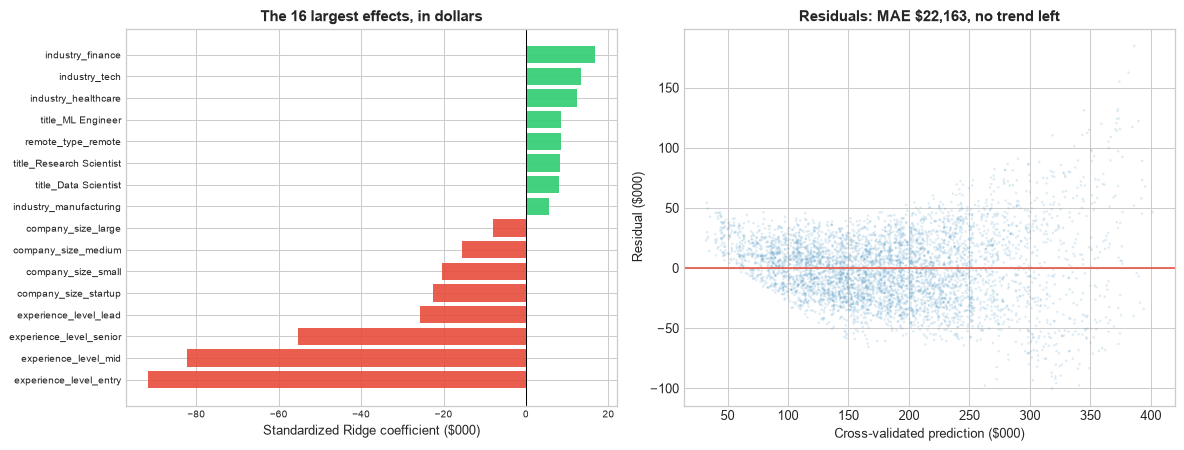

Residual mean $2, residual std $28,637
Share of postings predicted within $25k: 64.4%

The residual band widens with the prediction because the generator's 15-35%
spread is multiplicative, therefore an absolute-dollar metric penalises
director roles harder than entry ones. Report MAPE alongside MAE if that
asymmetry matters for the use case.


In [10]:
model = make_pipeline(StandardScaler(), Ridge()).fit(X_clean, y)
weights = pd.Series(model[-1].coef_, index=X_clean.columns).sort_values()
top = pd.concat([weights.head(8), weights.tail(8)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in top.values]
ax1.barh(top.index, top.values / 1000, color=colors, alpha=0.9)
ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_xlabel("Standardized Ridge coefficient ($000)")
ax1.set_title("The 16 largest effects, in dollars", fontweight="bold")
ax1.tick_params(labelsize=8)

resid_model = make_pipeline(StandardScaler(), Ridge())
from sklearn.model_selection import cross_val_predict

pred = cross_val_predict(resid_model, X_clean, y, cv=cv)
idx = np.random.default_rng(SEED).choice(len(y), 5000, replace=False)
ax2.scatter(pred[idx] / 1000, (y.values[idx] - pred[idx]) / 1000, s=4, alpha=0.15,
            color="#2980b9", edgecolors="none")
ax2.axhline(0, color="#e74c3c", linewidth=1.2)
ax2.set_xlabel("Cross-validated prediction ($000)")
ax2.set_ylabel("Residual ($000)")
ax2.set_title(f"Residuals: MAE ${mae_clean:,.0f}, no trend left", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Residual mean ${(y - pred).mean():,.0f}, residual std ${(y - pred).std():,.0f}")
print(f"Share of postings predicted within $25k: {((y - pred).abs() < 25000).mean():.1%}")
print()
print("The residual band widens with the prediction because the generator's 15-35%")
print("spread is multiplicative, therefore an absolute-dollar metric penalises")
print("director roles harder than entry ones. Report MAPE alongside MAE if that")
print("asymmetry matters for the use case.")


## 7. Where the Salary Actually Comes From <a id='drivers'></a>

Each of the six clean features is a multiplier in the generator. Their effect
sizes are worth reading side by side, because one of them dwarfs the rest.


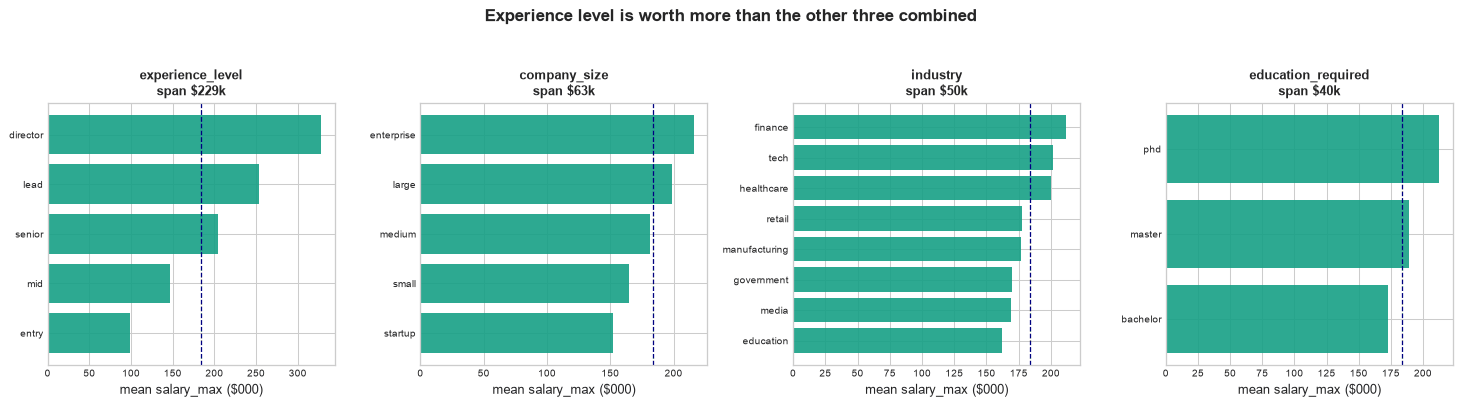

feature                                       low                       high       span
----------------------------------------------------------------------------------------
title                        UX Designer $170,079       ML Engineer $205,537 $   35,458
remote_type                       onsite $177,682            remote $195,659 $   17,977
industry                       education $161,957           finance $212,022 $   50,065
company_size                     startup $152,467        enterprise $215,916 $   63,449
experience_level                    entry $98,948          director $327,896 $  228,948
education_required              bachelor $172,721               phd $212,632 $   39,911

experience_level alone reaches R2 0.7116 (MAE $31,634); the other
five together add 0.1545 R2 and take $9,471 off the error.


In [11]:
DRIVERS = [
    ("experience_level", LEVEL_ORDER),
    ("company_size", SIZE_ORDER),
    ("industry", None),
    ("education_required", ["highschool", "bachelor", "master", "phd"]),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, (col, order) in zip(axes, DRIVERS):
    means = df.groupby(col)["salary_max"].mean()
    order = [o for o in (order or means.sort_values().index) if o in means.index]
    means = means.reindex(order)
    ax.barh(means.index, means.values / 1000, color="#16a085", alpha=0.9)
    ax.axvline(y.mean() / 1000, color="navy", linestyle="--", linewidth=1)
    ax.set_xlabel("mean salary_max ($000)")
    span = means.max() - means.min()
    ax.set_title(f"{col}\nspan ${span / 1000:,.0f}k", fontweight="bold", fontsize=10)
    ax.tick_params(labelsize=8)

plt.suptitle("Experience level is worth more than the other three combined",
             fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

print(f"{'feature':<22} {'low':>26} {'high':>26} {'span':>10}")
print("-" * 88)
for col in POSTING_TIME_FEATURES:
    means = df.groupby(col)["salary_max"].mean().sort_values()
    print(f"{col:<22} {means.index[0] + f' ${means.iloc[0]:,.0f}':>26} "
          f"{means.index[-1] + f' ${means.iloc[-1]:,.0f}':>26} "
          f"${means.iloc[-1] - means.iloc[0]:>9,.0f}")
print()
print(f"experience_level alone reaches R2 {r2_exp:.4f} (MAE ${mae_exp:,.0f}); the other")
print(f"five together add {r2_clean - r2_exp:.4f} R2 and take ${mae_exp - mae_clean:,.0f} "
      "off the error.")


## 8. Negative Controls: Four Columns That Carry Nothing <a id='nulls'></a>

Adding a feature almost always improves the training fit. The question is whether
it improves cross-validated *error*, and for four columns here the answer is no —
including one that correlates with the target at **+0.70** on its own.


In [12]:
CONTROLS = {
    "+ location (50 cities)": pd.get_dummies(df[["location"]], drop_first=True),
    "+ company (192 employers)": pd.get_dummies(df[["company"]], drop_first=True),
    "+ n_skills": df[["n_skills"]],
    "+ description length": df[["desc_len"]],
}

print("Does adding the column improve 5-fold cross-validated error?")
print("-" * 78)
print(f"{'clean baseline':<38} R2 {r2_clean:.4f}   MAE ${mae_clean:>7,.0f}")
control_results = {}
for label, extra in CONTROLS.items():
    r2_x, mae_x, _ = evaluate(pd.concat([X_clean, extra], axis=1), label)
    control_results[label] = (r2_x - r2_clean, mae_x - mae_clean)

print()
print(f"{'column added':<30} {'delta R2':>10} {'delta MAE':>12}")
print("-" * 56)
for label, (d_r2, d_mae) in control_results.items():
    print(f"{label:<30} {d_r2:>+10.4f} {d_mae:>+11,.0f}")

loc_means = df.groupby("location")["salary_max"].mean().sort_values()
print()
print(f"location spans ${loc_means.iloc[0]:,.0f} ({loc_means.index[0]}) to "
      f"${loc_means.iloc[-1]:,.0f} ({loc_means.index[-1]}) — "
      f"{(loc_means.max() - loc_means.min()) / y.mean():.1%} of the mean salary, "
      "spread over 50 cities.")
print("That is sampling noise, not a cost-of-living effect: the generator applies")
print("no geographic multiplier, so the famous San Francisco premium is absent.")


Does adding the column improve 5-fold cross-validated error?
------------------------------------------------------------------------------
clean baseline                         R2 0.8660   MAE $ 22,163
+ location (50 cities)                 R2 0.8656   MAE $ 22,199   RMSE $ 28,683
+ company (192 employers)              R2 0.8642   MAE $ 22,295   RMSE $ 28,827
+ n_skills                             R2 0.8660   MAE $ 22,162   RMSE $ 28,633
+ description length                   R2 0.8660   MAE $ 22,163   RMSE $ 28,634

column added                     delta R2    delta MAE
--------------------------------------------------------
+ location (50 cities)            -0.0005         +36
+ company (192 employers)         -0.0018        +132
+ n_skills                        +0.0000          -1
+ description length              -0.0000          +0

location spans $170,707 (Minneapolis, MN) to $191,495 (Tampa, FL) — 11.3% of the mean salary, spread over 50 cities.
That is sampling noise, not a

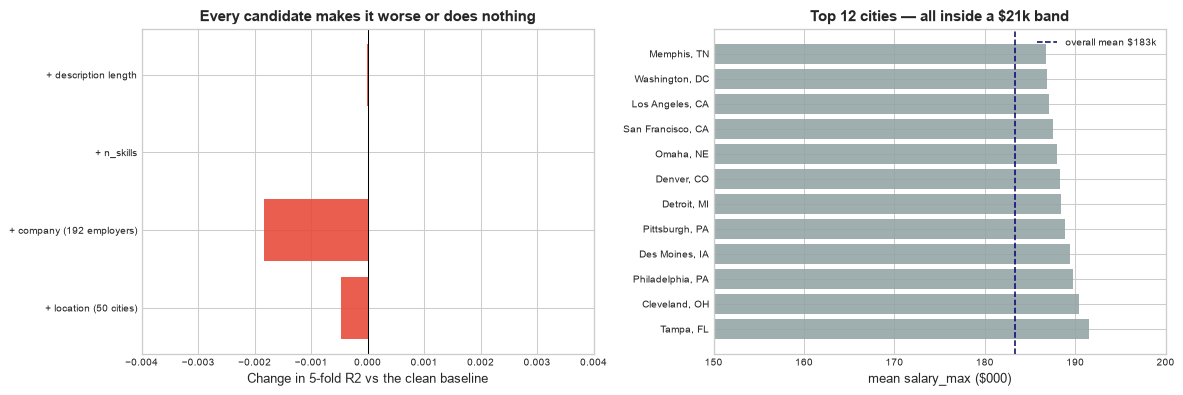

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

labels = list(control_results)
deltas = [control_results[k][0] for k in labels]
ax1.barh(labels, deltas, color=["#e74c3c" if d < 0 else "#2ecc71" for d in deltas],
         alpha=0.9)
ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_xlim(-0.004, 0.004)
ax1.set_xlabel("Change in 5-fold R2 vs the clean baseline")
ax1.set_title("Every candidate makes it worse or does nothing", fontweight="bold")
ax1.tick_params(labelsize=8)

top_cities = loc_means.tail(12)[::-1]
ax2.barh(top_cities.index, top_cities.values / 1000, color="#95a5a6", alpha=0.9)
ax2.axvline(y.mean() / 1000, color="navy", linestyle="--", linewidth=1.2,
            label=f"overall mean ${y.mean() / 1000:.0f}k")
ax2.set_xlim(150, 200)
ax2.set_xlabel("mean salary_max ($000)")
ax2.set_title("Top 12 cities — all inside a $21k band", fontweight="bold")
ax2.legend(fontsize=8)
ax2.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


## 9. Distributions <a id='distributions'></a>

The salary distribution is multimodal, and the modes are the experience levels.


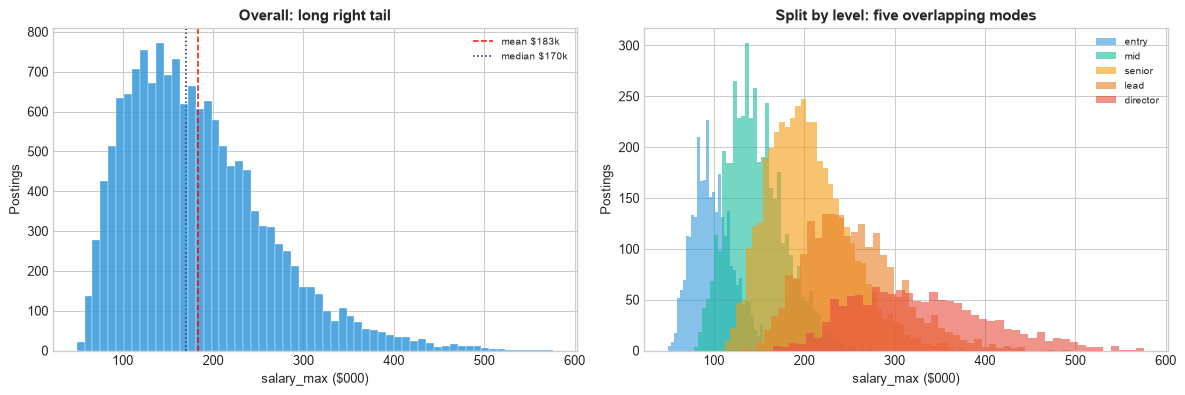

                  count      mean      std
experience_level                          
entry              3037   98948.0  22312.0
mid                4378  147024.0  31551.0
senior             4258  204555.0  43671.0
lead               2096  253693.0  52092.0
director           1231  327896.0  74397.0

Observation: the levels overlap heavily, which is why experience_level alone
leaves $31,634 of error. The company-size and industry multipliers are
what separate two postings at the same level.


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

ax1.hist(y / 1000, bins=60, color="#3498db", alpha=0.85, edgecolor="white", linewidth=0.3)
ax1.axvline(y.mean() / 1000, color="red", linestyle="--", linewidth=1.2,
            label=f"mean ${y.mean() / 1000:.0f}k")
ax1.axvline(y.median() / 1000, color="navy", linestyle=":", linewidth=1.2,
            label=f"median ${y.median() / 1000:.0f}k")
ax1.set_xlabel("salary_max ($000)")
ax1.set_ylabel("Postings")
ax1.set_title("Overall: long right tail", fontweight="bold")
ax1.legend(fontsize=8)

for level, color in zip(LEVEL_ORDER, palette):
    ax2.hist(df.loc[df["experience_level"] == level, "salary_max"] / 1000, bins=45,
             color=color, alpha=0.6, label=level)
ax2.set_xlabel("salary_max ($000)")
ax2.set_ylabel("Postings")
ax2.set_title("Split by level: five overlapping modes", fontweight="bold")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(df.groupby("experience_level")["salary_max"].agg(["count", "mean", "std"])
      .reindex(LEVEL_ORDER).round(0).to_string())
print()
print("Observation: the levels overlap heavily, which is why experience_level alone")
print(f"leaves ${mae_exp:,.0f} of error. The company-size and industry multipliers are")
print("what separate two postings at the same level.")


## 10. Correlation Analysis <a id='correlations'></a>

Only five columns in this table are numeric, and three of them are on the excluded
list. The heatmap is included to show exactly that, not to find features in it.


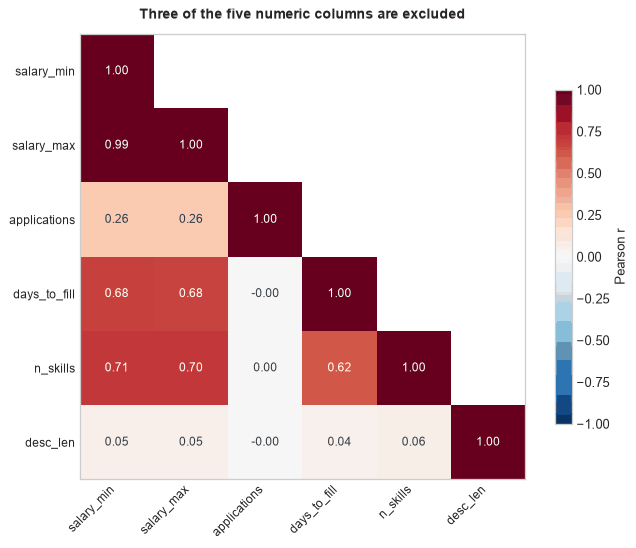

Correlation with salary_max, and the verdict from sections 4 and 5
------------------------------------------------------------------
  salary_min        +0.993   EXCLUDED
  n_skills          +0.704   usable
  days_to_fill      +0.679   EXCLUDED
  applications      +0.258   EXCLUDED
  desc_len          +0.047   usable

Caveat: two of the three strongest correlations here are on the excluded
list. Ranking features by correlation would have selected exactly the wrong
set, which is the argument for auditing before selecting.

n_skills is the instructive case: it correlates with salary at +0.704 marginally, yet section 8 measured that adding
it to the six categoricals changes R2 by 0.0000. The generator picks the
number of skills from the title and the experience level, therefore the
categoricals already contain everything it knows.


In [15]:
CORR_COLS = ["salary_min", "salary_max", "applications", "days_to_fill",
             "n_skills", "desc_len"]
corr = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
im = ax.imshow(np.ma.masked_array(corr.values, mask=mask), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR_COLS)))
ax.set_yticks(range(len(CORR_COLS)))
ax.set_xticklabels(CORR_COLS, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(CORR_COLS, fontsize=9)
ax.grid(False)
for i in range(len(CORR_COLS)):
    for j in range(i + 1):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(val) > 0.55 else "#2c3e50")
fig.colorbar(im, ax=ax, shrink=0.75, label="Pearson r")
ax.set_title("Three of the five numeric columns are excluded",
             fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

target_corr = corr["salary_max"].drop("salary_max").sort_values(key=abs, ascending=False)
print("Correlation with salary_max, and the verdict from sections 4 and 5")
print("-" * 66)
for name, value in target_corr.items():
    verdict = "EXCLUDED" if name in LEAKAGE_COLS else "usable"
    print(f"  {name:<16} {value:>+7.3f}   {verdict}")
print()
print("Caveat: two of the three strongest correlations here are on the excluded")
print("list. Ranking features by correlation would have selected exactly the wrong")
print("set, which is the argument for auditing before selecting.")
print()
print(f"n_skills is the instructive case: it correlates with salary at "
      f"{df['n_skills'].corr(y):+.3f} marginally, yet section 8 measured that adding")
print("it to the six categoricals changes R2 by 0.0000. The generator picks the")
print("number of skills from the title and the experience level, therefore the")
print("categoricals already contain everything it knows.")


## 11. Evaluation Readiness <a id='evaluation'></a>


In [16]:
print("Evaluation readiness checklist")
print("=" * 72)
print(f"Target                : {TARGET_COL}  (mean ${y.mean():,.0f}, sd ${y.std():,.0f})")
print(f"Task                  : {MODELING_TASK}")
print(f"Metric                : {PRIMARY_METRIC}")
print(f"Validation            : {VALIDATION_PLAN}")
print(f"Seed                  : {SEED}")
print()
print("Baseline to beat (all leakage removed):")
print(f"  random 5-fold       : R2 {r2_clean:.4f}, MAE ${mae_clean:,.0f}, "
      f"RMSE ${rmse_clean:,.0f}")
print(f"  company-grouped     : R2 {r2_grp:.4f}, MAE ${mae_grp:,.0f}")
print(f"  predict-the-mean    : R2 0.0000, MAE ${null_mae:,.0f}")
print()
print("Drop before fitting:")
print(f"  salary_min      algebraic: salary_max = salary_min x (1.15..1.35)")
print(f"  days_to_fill    post-hoc, and confounded by experience_level")
print(f"  applications    post-hoc, and confounded by company_size")
print(f"  job_id          identifier")
print()
print("Keep, but expect nothing (measured in section 8):")
print("  location, company, required_skills count, description length")
print()
print("If you want a harder task on this table:")
print("  - predict salary_min from the description text alone (the templates")
print("    mention the title and skills, so it is a real NLP problem)")
print("  - predict experience_level from required_skills, a genuine multiclass task")
print("  - predict days_to_fill from posting-time features only, which is the")
print("    forecasting version of the column excluded above")
print()
print("Risk checks:")
print("  - re-run the within-group correlation test on any new numeric feature")
print("  - group by company when the model can see company identity")
print("  - report MAPE next to MAE; the error scales with the salary")


Evaluation readiness checklist
Target                : salary_max  (mean $183,370, sd $78,275)
Task                  : regression
Metric                : MAE in dollars (RMSE and R2 alongside)
Validation            : KFold(5, shuffle=True, random_state=42) + GroupKFold on company
Seed                  : 42

Baseline to beat (all leakage removed):
  random 5-fold       : R2 0.8660, MAE $22,163, RMSE $28,633
  company-grouped     : R2 0.8660, MAE $22,169
  predict-the-mean    : R2 0.0000, MAE $61,767

Drop before fitting:
  salary_min      algebraic: salary_max = salary_min x (1.15..1.35)
  days_to_fill    post-hoc, and confounded by experience_level
  applications    post-hoc, and confounded by company_size
  job_id          identifier

Keep, but expect nothing (measured in section 8):
  location, company, required_skills count, description length

If you want a harder task on this table:
  - predict salary_min from the description text alone (the templates
    mention the title and ski

## 12. Key Findings & Takeaways <a id='findings'></a>

Every number below is printed by a cell above or drawn on a chart in it.

### Finding 1 — `salary_min` reconstructs the target by division
The ratio `salary_max / salary_min` spans only **1.139 to 1.364** and lies inside
**[1.10, 1.40]** for **100%** of the 15,000 postings; the two columns correlate at
**r = 0.993**. The generator draws `salary_max = salary_min × (1 + U(0.15, 0.35))`,
so a model handed both is inverting arithmetic, not learning a labour market.

### Finding 2 — the two subtle leaks are confounders, and the test is conditioning
`days_to_fill` correlates with salary at **+0.679** overall and at between
**−0.035 and +0.019** once `experience_level` is held fixed. `applications` goes
from **+0.258** to between **−0.019 and +0.034** once `company_size` is held fixed.
Both collapse completely, **therefore** neither carries information the categorical
columns do not already have. Both are also unknowable on the day a posting is
published, which disqualifies them a second time.

### Finding 3 — the clean model is strong and it generalises
Six posting-time categoricals reach 5-fold **R² 0.866**, MAE **\$22,163**, RMSE
**\$28,633**, against a predict-the-mean MAE of **\$61,767** — a **64%** reduction
in error. Holding out **whole companies** gives **R² 0.866** and MAE **\$22,169**,
essentially identical, so the model is reading posting attributes rather than
memorising the 192 employers.

### Finding 4 — experience level is worth more than everything else combined
`experience_level` alone reaches **R² 0.712** (MAE **\$31,634**); the other five
features together add **0.154** R² and remove a further **\$9,471** of error. The
level spans **\$98,948** (entry) to **\$327,896** (director), against **\$152,467**
to **\$215,916** for company size and **\$161,957** to **\$212,022** for industry.

### Finding 5 — marginal correlation and conditional value are different things
`n_skills` correlates with `salary_max` at **+0.704**, which would put it near the
top of any correlation-ranked feature list. Added to the six categoricals it moves
cross-validated R² by **0.0000** — the skill count is drawn from the title and the
experience level, **therefore** the categoricals already carry it. `location` is the
other surprise: fifty US cities span **\$170,707** to **\$191,495**, **11.3%** of
the mean salary, and adding them changes R² by **−0.0005**. No geographic multiplier
exists in this generator, so the table cannot be used to study regional pay.
Company identity (**−0.0018**) and description length (**−0.0000**) are the same
story.

### Trade-offs, limitations, and caveats
- **Limitation — synthetic.** These are properties of `create_dataset.py`, not of
  hiring. The value is a known ground truth to test a leakage audit against.
- **Trade-off — dropping `salary_min` costs a lot of apparent accuracy.** It is
  still correct: a range endpoint is not a feature, it is half the answer, and a
  deployed model predicting a posted range would have neither end of it.
- **Caveat — correlation ranking would have picked the wrong features.** The two
  highest-correlating usable-looking columns are precisely the two excluded ones.
  Rank by correlation on this table and you build the undeployable model.
- **Caveat — the error is heteroscedastic.** Residuals widen with the prediction
  because the generator's spread is multiplicative, so MAE understates the error on
  entry roles and overstates it on director roles relative to MAPE.
- **Caveat — the text is templated.** All 15,000 descriptions are distinct strings,
  but they come from a small set of templates with the title and skills
  interpolated. Enough to wire up an NLP pipeline; not enough to benchmark one.

### Next steps
- **Recommend** publishing the dataset with `salary_min`, `days_to_fill` and
  `applications` explicitly flagged in the description as excluded-by-default, and
  the **\$22,163** MAE above quoted as the baseline to beat.
- Try target encoding on `title × industry × company_size` inside each fold; the
  generator multiplies these factors, so a model that can only add them is leaving
  interaction structure on the table.
- Fit the same model on `log(salary_max)` and compare MAPE, which the residual plot
  argues is the better-matched metric.
- Build the genuine NLP task: predict `experience_level` from `required_skills` and
  `description`, where no numeric shortcut exists.
